In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configurable paths

# Promoter-level chec-seq signal (sumprom) for Human TFs
sumprom_chec_glob = "sumproms/*gz"

# Promoter-level chec-seq signal (sumprom) for yeast TFs (see manuscript)
yeast_tf_sumprom_glob = '../Yeast_Native_TF_outfiles/results/sumproms/*.gz'

# Promoter-level chec-seq signal (sumprom) for yeast DBD-only variants (see manuscript)
yeast_dbd_variants_glob = "../divya_dbds/results/sumproms/*.gz"

# OPN scores per promoter
opn_scores_glob = "metadata/comp_gp.csv"

# Sequence metadata calculated for figure 2E, showing IDR length
sequence_metadata_glob = "../calculations_for_publication/metadata_seq_calculations_fig2.csv"

## Imports

In [3]:
import numpy as np
import pandas as pd

import glob

from scipy.stats import zscore
from scipy.stats import spearmanr

import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [4]:
FOXK1_WT = ["FOXP3","FOXA2","FOXF1","FOXL1","FOXL2","FOXJ2","FOXO3","FOXP1","FOXP2"]
GABPA_WT = ["ELF1","ELF2","ERF1","ELK1","ELK4","ERG","FLI1"]
SOX10_WT = ["SOX15","SOX17","SOX7","SOX11","SOX4","SOX6","SOX30","SOX9","SOX13","SOX5"]
HXD10_WT = ["CDX2","HOXA11","HOXC10","HOXD9","HOXA10","HOXC9","HOXA9","HOXB9","CDX4","HOXC13"]
GATA1_WT = ["GATA3","GATA6","GATA4","GATA2","GATA5"]
BATF3_WT = ["ATF4","FOS","CREB5","ATF1","CREB1","ATF2"]
HEY1_WT = ["MNT","MLXIPL","MLX","MXD4"]
NFAC4_WT = ["NFATC4","NFATC3"]
TF2LY_WT = ["TGIF2LX","TGIF2LY","TGIF1","TGIF2"]
PO3F2_WT = ["POU2F3","POU3F4","POU3F1"]

dbd_fam_dict = {"FOXK1": FOXK1_WT, "GABPA": GABPA_WT, "SOX10": SOX10_WT, "HXD10": HXD10_WT, "GATA1": GATA1_WT, "BATF3": BATF3_WT, "HEY1": HEY1_WT, "NFAC4": NFAC4_WT, "TF2LY": TF2LY_WT, "PO3F2": PO3F2_WT}

In [5]:
sumprom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in sumprom_chec_files], axis=1)

corr_cutoff = 0.895

def filter_reproducible(sumprom_all: pd.DataFrame, cutoff) -> pd.DataFrame:
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]
    
    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]

sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit('_', n=2).str[0]
cols_to_keep = set(sum(dbd_fam_dict.values(), []))
sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
sumprom = sumprom.loc[:, sumprom.columns.intersection(cols_to_keep)]
sumprom_z = sumprom.apply(zscore)

In [6]:
native_tf_sumprom_files = glob.glob(yeast_tf_sumprom_glob)
native_tf_sumprom = pd.concat([pd.read_parquet(x) for x in native_tf_sumprom_files], axis=1)
non_transcription_factors = ['Nfi1', 'Itc1', 'Gal11', 'Nhp6A', 'Spt20', 'Nhp6B','Abf2', 'Tog1', 'Siz1', 'Cyc8', "Mss11"]
native_tf_sumprom = native_tf_sumprom.drop(columns=non_transcription_factors)
native_tf_sumprom_z = native_tf_sumprom.apply(zscore)

In [7]:
dbd_chec_files = glob.glob(yeast_dbd_variants_glob)
dbd_sumprom_reps = pd.concat([pd.read_parquet(x) for x in dbd_chec_files], axis=1)
dbd_sumprom_filtered = filter_reproducible(dbd_sumprom_reps, cutoff=corr_cutoff)
cols = pd.Index(dbd_sumprom_filtered.columns)
prefix = cols.to_series().str.rsplit("_", n=3).str[0]
sumprom_dbd = dbd_sumprom_filtered.T.groupby(prefix).mean().T
sumprom_dbd.columns = sumprom_dbd.columns.astype(str) + "_DBD"
sumprom_dbd_z = sumprom_dbd.apply(zscore)

In [8]:
opn_scores_unfiltered = pd.read_csv(opn_scores_glob, index_col='name').iloc[:,1:]
opn_scores = opn_scores_unfiltered[opn_scores_unfiltered.index.isin(sumprom.index)]

## Plot

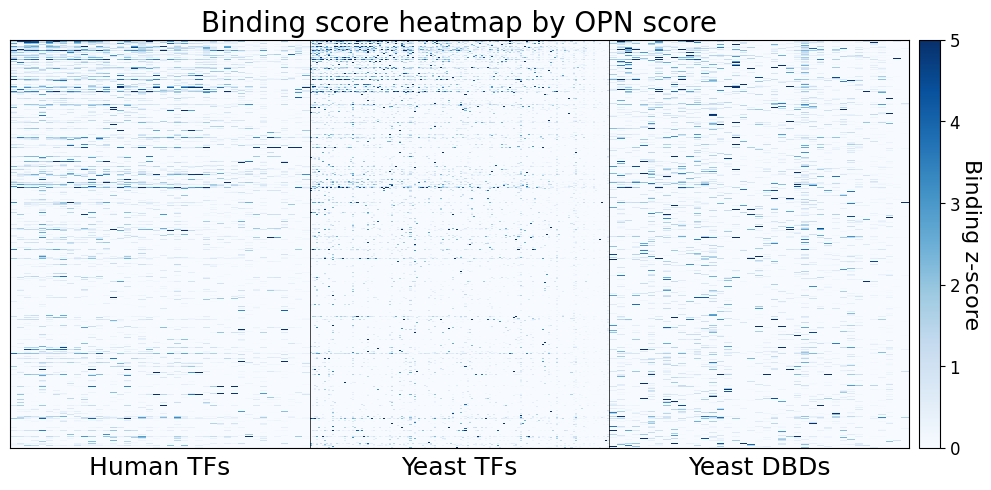

In [9]:
z_cutoff = 3

combined_sumprom = pd.concat([sumprom_z, native_tf_sumprom_z, sumprom_dbd_z], axis=1)

# row order by OPN score (high -> low)
row_order = opn_scores.loc[combined_sumprom.index, "opn_score"].sort_values(ascending=False).index
df_ordered = combined_sumprom.loc[row_order]

# 1) Split column groups (human left, yeast TFs middle, yeast DBDs right)
human_cols = list(sumprom_z.columns)
yeast_cols = list(native_tf_sumprom_z.columns)
yeast_dbd_cols = list(sumprom_dbd_z.columns)

# 2) Sort columns within each group by #rows with z > cutoff
human_cols_sorted = (df_ordered[human_cols] > z_cutoff).sum(axis=0).sort_values(ascending=False).index.tolist()
yeast_cols_sorted = (df_ordered[yeast_cols] > z_cutoff).sum(axis=0).sort_values(ascending=False).index.tolist()
yeast_dbd_cols_sorted = (df_ordered[yeast_dbd_cols] > z_cutoff).sum(axis=0).sort_values(ascending=False).index.tolist()

# 3) Reorder columns AND keep OPN-ordered rows
df = df_ordered[human_cols_sorted + yeast_cols_sorted + yeast_dbd_cols_sorted]

# 4) Heatmap
fig, ax = plt.subplots(figsize=(11, 5))

n_rows = df.shape[0]
n_human = len(human_cols_sorted)
n_yeast = len(yeast_cols_sorted)
n_dbd = len(yeast_dbd_cols_sorted)

# Make all three panels equal width (1/3 each)
x_edges_h = np.linspace(0.0, 1/3, n_human + 1)
x_edges_y = np.linspace(1/3, 2/3, n_yeast + 1)
x_edges_d = np.linspace(2/3, 1.0, n_dbd + 1)
x_edges = np.concatenate([x_edges_h, x_edges_y[1:], x_edges_d[1:]])
y_edges = np.arange(n_rows + 1)

im = ax.pcolormesh(
    x_edges,
    y_edges,
    df.values,
    cmap="Blues",
    vmin=0,
    vmax=5,
    shading="flat",
)

# put first row at top (match imshow default appearance)
ax.set_ylim(n_rows, 0)

ax.axvline(1/3, color="black", linewidth=0.5)
ax.axvline(2/3, color="black", linewidth=0.5)

human_center = 1/6
yeast_center = 0.5
yeast_dbd_center = 5/6

y_text = n_rows + n_rows * 0.02  # slightly below the plot

ax.text(human_center, y_text, "Human TFs",
        ha="center", va="top", fontsize=18, clip_on=False)

ax.text(yeast_center, y_text, "Yeast TFs",
        ha="center", va="top", fontsize=18, clip_on=False)

ax.text(yeast_dbd_center, y_text, "Yeast DBDs",
        ha="center", va="top", fontsize=18, clip_on=False)

ax.set_xticks([])
ax.set_yticks([])

ax.set_title("Binding score heatmap by OPN score", fontsize=20)

cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.set_label("Binding z-score", fontsize=16, rotation=270, labelpad=15)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()


In [10]:
metadata = pd.read_csv(sequence_metadata_glob, index_col=0)

All TFs: ρ=0.30
TFs w/o HOX: ρ=0.53


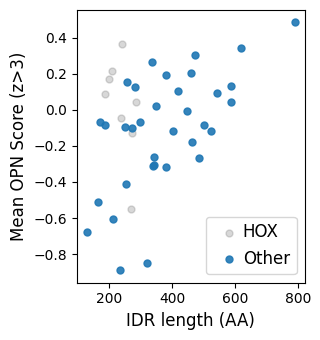

In [11]:
z_cutoff = 3

# Map sample → IDR length
idr = metadata.set_index("Name")["IDR_count"]

# Compute mean opn_score for bound targets per sample
mean_opn = {
    sample: opn_scores.loc[sumprom_z[sample] > z_cutoff, "opn_score"].mean()
    for sample in sumprom_z.columns
}
mean_opn = pd.Series(mean_opn)

x = idr.loc[mean_opn.index]
y = mean_opn

# Define groups
is_hox = mean_opn.index.isin(HXD10_WT)

# Compute Spearman correlations
r_hox, _ = spearmanr(x, y)
r_other, _ = spearmanr(x[~is_hox], y[~is_hox])

# Scatter plot
plt.figure(figsize=(3.3, 3.5))

plt.scatter(
    x[is_hox],
    y[is_hox],
    s=25,
    label="HOX",
    c="grey",
    alpha=0.3
)
print(f"All TFs: ρ={r_hox:.2f}")

plt.scatter(
    x[~is_hox],
    y[~is_hox],
    s=25,
    label="Other",
    c="tab:blue",
    alpha=0.9
)
print(f"TFs w/o HOX: ρ={r_other:.2f}")

plt.xlabel("IDR length (AA)", fontsize=12)
plt.ylabel(f"Mean OPN Score (z>{z_cutoff})", fontsize=12)

# Reduce space between marker and text
plt.legend(loc="lower right", fontsize=12, handletextpad=-0.2)

plt.tight_layout()
plt.show()